# Atlas subset to epithelial / target cell-states

* **Developed by:** Anna Maguza
* **Affilation:** CellZome, a GSK company
* **Created date:** 2026-05-08
* **Last modified date:** 2026-05-13

Subset the 13 GB human atlas to Epithelial + 6 cell-states for downstream comparison.


## 1. Imports and paths

In [35]:
import os, sys, gc, json, datetime as dt
from pathlib import Path
import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad
import matplotlib.pyplot as plt
import seaborn as sns

In [36]:
sc.settings.verbosity = 2
sc.settings.dpi = 120
sc.settings.dpi_save = 300
plt.rcParams.update({
    'savefig.bbox': 'tight', 'savefig.dpi': 300, 'figure.dpi': 120,
    'font.family': ['Arial', 'Helvetica', 'DejaVu Sans'], 'font.size': 10,
    'axes.spines.top': False, 'axes.spines.right': False,
})

In [37]:
REPO         = Path('/Users/am336941/Library/CloudStorage/OneDrive-GSK/Desktop/Fetal_stem_cells_analysis')
DATA_OUT     = Path('/Users/am336941/PhD/data/Fetal_stem_cells_analysis_enhanced')
ATLAS_PATH   = Path('/Users/am336941/PhD/data/gut_data/gut_hs_all_datasets_full_annotated_AM_30102025_181544_raw.h5ad')
LGR5_DIR     = REPO / 'data' / 'LGR5_analysis'
ORTH_PATH    = Path('/Users/am336941/PhD/data/LGR5_analysis_data/human_mouse_orthologues_ensembl.txt')
DATA_OUT.mkdir(parents=True, exist_ok=True)

In [38]:
def stamp() -> str:
    return dt.datetime.now().strftime('%d%m%Y_%H%M%S')

In [39]:
def X_is_raw(adata):
    # adata.X may be a backed _CSRDataset; slice a small chunk into memory first
    chunk = adata.X[:200]
    if hasattr(chunk, 'toarray'):
        chunk = chunk.toarray()
    return np.array_equal(chunk.astype(int), chunk)


## 2. Load the full atlas (backed mode, 13 GB)

In [40]:
adata = sc.read_h5ad(ATLAS_PATH, backed='r')
print('shape', adata.shape)
print('obs columns:', list(adata.obs.columns))
print(adata.obs[['Study_name','age_group','organism_part','gut_region','celltype','cell_states']].head())

shape (387076, 43704)
obs columns: ['cell_index', 'Source Name', 'ENA_SAMPLE', 'BioSD_SAMPLE', 'organism', 'disease', 'organism_part', 'cell_type', 'growth_condition', 'developmental_stage', 'Material Type', 'Protocol REF', 'sample_id', 'LIBRARY_LAYOUT', 'cdna_read_size', 'cell_barcode_size', 'end_bias', 'library_construction', 'sample_barcode_size', 'umi_barcode_offset', 'umi_barcode_size', 'Performer', 'Assay Name', 'ENA_EXPERIMENT', 'ENA_RUN', 'time', 'time_unit', 'n_genes', 'doublet_scores', 'predicted_doublets', 'n_counts', 'log1p_n_counts', 'log1p_n_genes', 'percent_mito', 'n_counts_mito', 'percent_ribo', 'n_counts_ribo', 'percent_hb', 'n_counts_hb', 'percent_top50', 'cell_passed_qc', 'qc_cluster', 'cluster_passed_qc', 'consensus_fraction', 'consensus_passed_qc', 'total_counts', 'n_genes_by_counts', 'percent_chrY', 'XIST-counts', 'XIST-percentage', 'sex', 'S_score', 'G2M_score', 'Cell_cycle_phase', 'Study_name', 'ArrayExpress_ID', 'library_preparation_protocol', 'full_age', 'age_

In [41]:
X_is_raw(adata)

True

## 3. Subset to Epithelial cells with target cell-states

Target cell_states: `Stem cells`, `TA`, `Enterocyte`, `Proximal progenitor`, `Distal progenitor`, `Colonocyte`. Stem cells are kept as a single group (no longer split into FXYD3+_CKB+_SC etc.).

In [42]:
TARGET_STATES = ['Stem cells', 'TA', 'Enterocyte',
                 'Proximal progenitor', 'Distal progenitor', 'Colonocyte']

mask = (adata.obs['celltype'] == 'Epithelial') & adata.obs['cell_states'].isin(TARGET_STATES)
print(f'keeping {int(mask.sum()):,} / {adata.n_obs:,} cells')
print(adata.obs.loc[mask, 'cell_states'].value_counts())

# materialise the subset (out of backed mode)
sub = adata[mask].to_memory()
sub.obs['cell_states'] = pd.Categorical(sub.obs['cell_states'], categories=TARGET_STATES, ordered=True)
del adata; gc.collect()


keeping 95,357 / 387,076 cells
cell_states
Enterocyte             28751
Proximal progenitor    26304
TA                     15143
Stem cells             13495
Colonocyte             11415
                       ...  
ICC                        0
I cells (CCK+)             0
Goblet cell                0
Glia                       0
venous capillary           0
Name: count, Length: 99, dtype: int64


109321

Subset to all epithelial

In [43]:
#mask = (adata.obs['celltype'] == 'Epithelial')
#print(f'keeping {int(mask.sum()):,} / {adata.n_obs:,} cells')
#print(adata.obs.loc[mask, 'cell_states'].value_counts())

In [44]:
# materialise the subset (out of backed mode)
#sub = adata[mask].to_memory()
#sub.obs['cell_states'] = pd.Categorical(sub.obs['cell_states'], ordered=True)
#del adata; gc.collect()

## 4. Quick QC summary

In [45]:
display(sub.obs.groupby(['Study_name','age_group','cell_states'], observed=True).size().unstack(fill_value=0))
display(sub.obs.groupby(['gut_region','organism_part'], observed=True).size())


cell_states                          Stem cells    TA  Enterocyte  \
Study_name       age_group                                          
Elementaite_2021 adult                     2547  2328        4491   
                 cell culture model        2175  2787        1714   
                 child stage                201   256         106   
                 first trimester            893  3192        4485   
                 second trimester          1495  1158        4115   
Holloway_2021    cell culture model        1264  1484        1317   
                 first trimester           2814  3411        6783   
                 second trimester          2106   527        5740   

cell_states                          Proximal progenitor  Distal progenitor  \
Study_name       age_group                                                    
Elementaite_2021 adult                              4044                  0   
                 cell culture model                 3489                 15   
                 child stage                          57                  0   
                 first trimester                   10841                182   
                 second trimester                   1511                 10   
Holloway_2021    cell culture model                 1540                 33   
                 first trimester                    3600                  6   
                 second trimester                   1222                  3   

cell_states                          Colonocyte  
Study_name       age_group                       
Elementaite_2021 adult                     1542  
                 cell culture model          74  
                 child stage                  3  
                 first trimester            253  
                 second trimester           636  
Holloway_2021    cell culture model         263  
                 first trimester           2854  
                 second trimester          5790

gut_region       organism_part   
large intestine  appendix              552
                 ascending colon      1347
                 caecum               1479
                 colon                3527
                 descending colon      441
                 large intestine       716
                 rectum                387
                 sigmoid colon        3426
                 transverse colon     1653
small intestine  duodenum            46599
                 ileum               26910
                 jejunum               357
                 small intestine      7340
                 terminal ileum        623
dtype: int64

## 5. Sanity-check canonical ISC markers

present: ['LGR5', 'OLFM4', 'ASCL2', 'SMOC2', 'AXIN2', 'MKI67', 'MUC2', 'LYZ']
missing: ['CHGA']


saving figure to file figures/violin_stem_markers.png


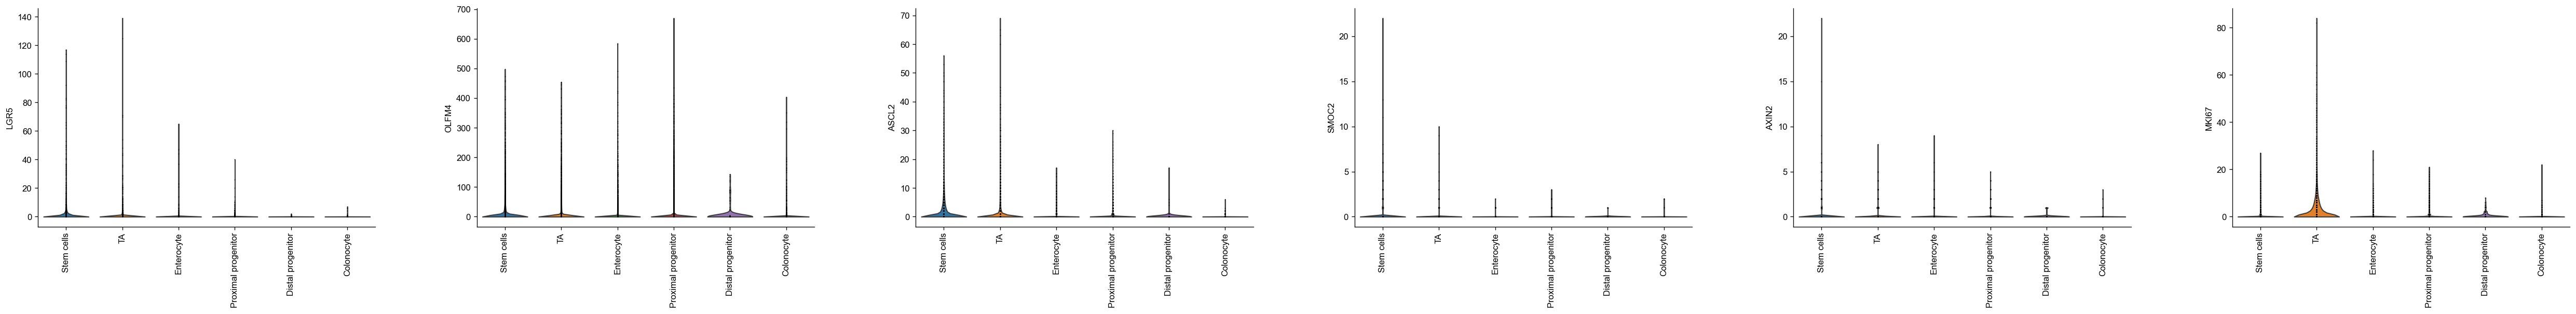

In [46]:
# raw counts assumed in .X (per CLAUDE.md naming `..._raw.h5ad`)
markers = ['LGR5','OLFM4','ASCL2','SMOC2','AXIN2','MKI67','MUC2','LYZ','CHGA']
present = [g for g in markers if g in sub.var_names]
missing = [g for g in markers if g not in sub.var_names]
print('present:', present)
print('missing:', missing)
sc.pl.violin(sub, keys=present[:6], groupby='cell_states', rotation=90, jitter=0.0, show=True, save="_stem_markers.png")


## 6. Append processing history & save

In [47]:
_existing = sub.uns.get('processing_history', {})
proc = dict(_existing) if isinstance(_existing, dict) else {'previous': _existing}
proc[f'epithelial_subset_{stamp()}'] = {
    'script': '0a_atlas_subset_epithelial.ipynb',
    'kept_celltype': 'Epithelial',
    #'kept_cell_states': TARGET_STATES,
    'n_cells': int(sub.n_obs),
    'n_genes': int(sub.n_vars),
}
sub.uns['processing_history'] = proc

out = DATA_OUT / f'gut_hs_atlas_epithelial_AM_{stamp()}_raw.h5ad'
sub.write_h5ad(out, compression='gzip')
print('saved', out, f'({out.stat().st_size/1e9:.2f} GB)')


saved /Users/am336941/PhD/data/Fetal_stem_cells_analysis_enhanced/gut_hs_atlas_epithelial_AM_13052026_144012_raw.h5ad (1.05 GB)
